In [6]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# Veriyi yükle
df = pd.read_csv('../../data/amzn_stock.csv')
close_prices = df['Close'].values.reshape(-1, 1)

# Ölçekle
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

# Kayan pencere
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_prices, lookback)

# Train/test split (kronolojik)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Tensöre çevir
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print("Veri hazır:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Veri hazır: torch.Size([2399, 20, 1]) torch.Size([2399, 1]) torch.Size([600, 20, 1]) torch.Size([600, 1])


In [ ]:
print("test")

In [1]:
print("test")

test


In [7]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model_lstm = LSTMModel()
print(model_lstm)

LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [3]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU katmanı: LSTM'e çok benzer ama daha basit iç yapı (2 kapı, cell state yok)
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # GRU'da SADECE hidden state (h0) var, LSTM'deki gibi ayrı bir cell state (c0) yok
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

model_gru = GRUModel()
print(model_gru)

GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [8]:
import torch.optim as optim

# Kayıp fonksiyonu ve optimizer (3. Haftada öğrendiğimiz gibi)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.001)

num_epochs = 50

for epoch in range(num_epochs):
    model_lstm.train()  # modeli "eğitim modu"na al
    
    optimizer.zero_grad()
    y_pred = model_lstm(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\nLSTM eğitimi tamamlandı!")

Epoch 10/50, Loss: 0.258922
Epoch 20/50, Loss: 0.079648
Epoch 30/50, Loss: 0.051582
Epoch 40/50, Loss: 0.036947
Epoch 50/50, Loss: 0.029920

LSTM eğitimi tamamlandı!


In [9]:
criterion_gru = nn.MSELoss()
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

num_epochs = 50

for epoch in range(num_epochs):
    model_gru.train()
    
    optimizer_gru.zero_grad()
    y_pred = model_gru(X_train)
    loss = criterion_gru(y_pred, y_train)
    loss.backward()
    optimizer_gru.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\nGRU eğitimi tamamlandı!")

Epoch 10/50, Loss: 0.242534
Epoch 20/50, Loss: 0.020231
Epoch 30/50, Loss: 0.036887
Epoch 40/50, Loss: 0.019934
Epoch 50/50, Loss: 0.017870

GRU eğitimi tamamlandı!


In [10]:
model_lstm.eval()  # değerlendirme modu (dropout vb. varsa kapatır)
model_gru.eval()

with torch.no_grad():  # gradyan hesaplamaya gerek yok, sadece tahmin yapıyoruz
    y_pred_lstm = model_lstm(X_test)
    y_pred_gru = model_gru(X_test)

# MSE/RMSE hesapla (2. Haftada öğrendiğimiz gibi)
mse_lstm = criterion(y_pred_lstm, y_test).item()
mse_gru = criterion_gru(y_pred_gru, y_test).item()

rmse_lstm = mse_lstm ** 0.5
rmse_gru = mse_gru ** 0.5

print(f"LSTM  -> Test MSE: {mse_lstm:.6f}, Test RMSE: {rmse_lstm:.6f}")
print(f"GRU   -> Test MSE: {mse_gru:.6f}, Test RMSE: {rmse_gru:.6f}")

LSTM  -> Test MSE: 0.861617, Test RMSE: 0.928233
GRU   -> Test MSE: 0.417951, Test RMSE: 0.646492


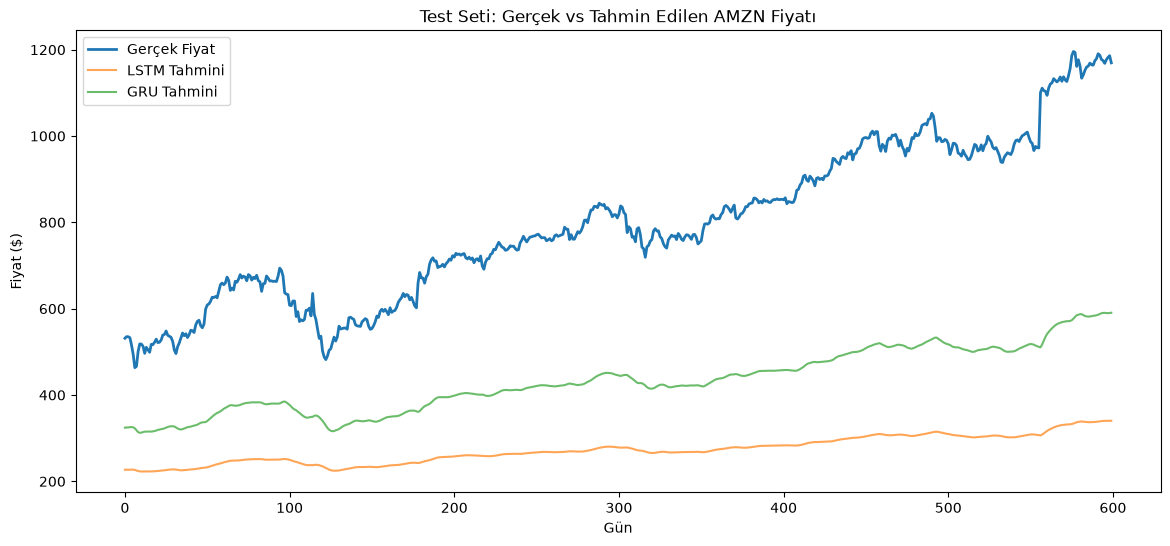

In [12]:
import matplotlib.pyplot as plt
# Ölçeklenmiş tahminleri gerçek dolar değerine geri çevir
y_test_actual = scaler.inverse_transform(y_test.numpy())
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm.numpy())
y_pred_gru_actual = scaler.inverse_transform(y_pred_gru.numpy())

plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Gerçek Fiyat', linewidth=2)
plt.plot(y_pred_lstm_actual, label='LSTM Tahmini', alpha=0.7)
plt.plot(y_pred_gru_actual, label='GRU Tahmini', alpha=0.7)
plt.title('Test Seti: Gerçek vs Tahmin Edilen AMZN Fiyatı')
plt.xlabel('Gün')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.show()

In [1]:
model_lstm = LSTMModel()
model_gru = GRUModel()

criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

num_epochs = 200

print("=== LSTM Eğitimi ===")
for epoch in range(num_epochs):
    model_lstm.train()
    optimizer_lstm.zero_grad()
    y_pred = model_lstm(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_lstm.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\n=== GRU Eğitimi ===")
for epoch in range(num_epochs):
    model_gru.train()
    optimizer_gru.zero_grad()
    y_pred = model_gru(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_gru.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\nİkisi de tamamlandı!")


NameError: name 'LSTMModel' is not defined

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- Veri hazırlığı ---
df = pd.read_csv('../../data/amzn_stock.csv')
close_prices = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_prices = scaler.fit_transform(close_prices)

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 20
X, y = create_sequences(scaled_prices, lookback)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print("Veri hazır:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# --- Model tanımları ---
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

print("Modeller tanımlandı.")

Veri hazır: torch.Size([2399, 20, 1]) torch.Size([2399, 1]) torch.Size([600, 20, 1]) torch.Size([600, 1])
Modeller tanımlandı.


In [3]:
model_lstm = LSTMModel()
model_gru = GRUModel()

criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

num_epochs = 200

print("=== LSTM Eğitimi ===")
for epoch in range(num_epochs):
    model_lstm.train()
    optimizer_lstm.zero_grad()
    y_pred = model_lstm(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_lstm.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\n=== GRU Eğitimi ===")
for epoch in range(num_epochs):
    model_gru.train()
    optimizer_gru.zero_grad()
    y_pred = model_gru(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_gru.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\nİkisi de tamamlandı!")

=== LSTM Eğitimi ===
Epoch 50/200, Loss: 0.035896
Epoch 100/200, Loss: 0.019946
Epoch 150/200, Loss: 0.001024
Epoch 200/200, Loss: 0.000605

=== GRU Eğitimi ===
Epoch 50/200, Loss: 0.026144
Epoch 100/200, Loss: 0.009457
Epoch 150/200, Loss: 0.000180
Epoch 200/200, Loss: 0.000167

İkisi de tamamlandı!


In [4]:
model_lstm.eval()
model_gru.eval()

with torch.no_grad():
    y_pred_lstm = model_lstm(X_test)
    y_pred_gru = model_gru(X_test)

mse_lstm = criterion(y_pred_lstm, y_test).item()
mse_gru = criterion(y_pred_gru, y_test).item()

rmse_lstm = mse_lstm ** 0.5
rmse_gru = mse_gru ** 0.5

print(f"LSTM -> Test MSE: {mse_lstm:.6f}, Test RMSE: {rmse_lstm:.6f}")
print(f"GRU  -> Test MSE: {mse_gru:.6f}, Test RMSE: {rmse_gru:.6f}")

LSTM -> Test MSE: 0.257828, Test RMSE: 0.507767
GRU  -> Test MSE: 0.034690, Test RMSE: 0.186251


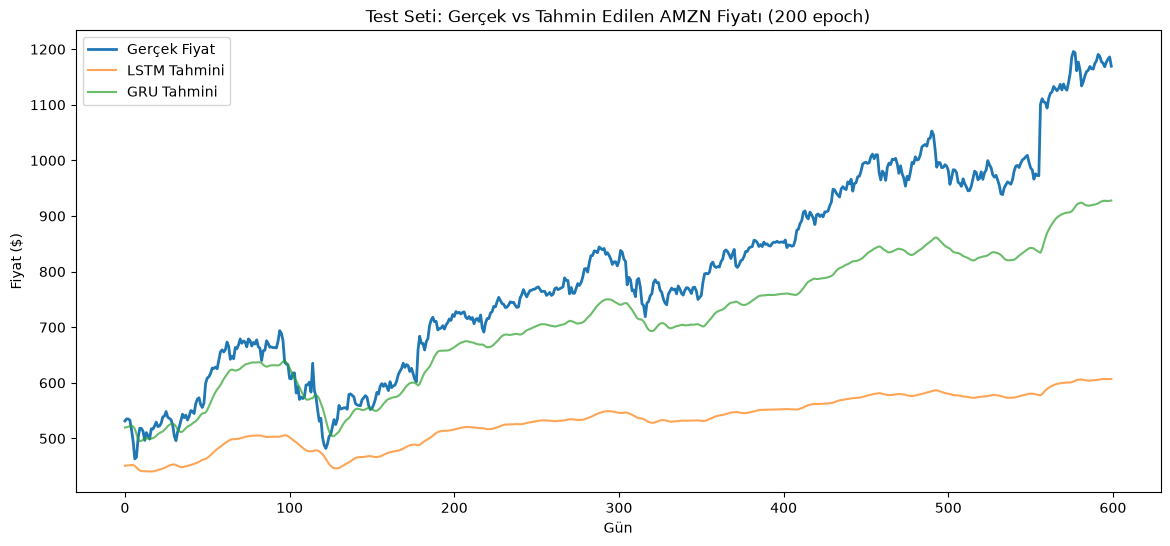

In [5]:
y_test_actual = scaler.inverse_transform(y_test.numpy())
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm.numpy())
y_pred_gru_actual = scaler.inverse_transform(y_pred_gru.numpy())

plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Gerçek Fiyat', linewidth=2)
plt.plot(y_pred_lstm_actual, label='LSTM Tahmini', alpha=0.7)
plt.plot(y_pred_gru_actual, label='GRU Tahmini', alpha=0.7)
plt.title('Test Seti: Gerçek vs Tahmin Edilen AMZN Fiyatı (200 epoch)')
plt.xlabel('Gün')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.show()

In [6]:
# --- Yeni lookback ile veriyi yeniden hazırla ---
lookback = 30  # 20 yerine 30

X, y = create_sequences(scaled_prices, lookback)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print("Yeni veri boyutları:", X_train.shape, X_test.shape)

# --- Modelleri sıfırdan oluştur ve eğit ---
model_lstm = LSTMModel()
model_gru = GRUModel()

criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

num_epochs = 200

print("\n=== LSTM Eğitimi (lookback=30) ===")
for epoch in range(num_epochs):
    model_lstm.train()
    optimizer_lstm.zero_grad()
    y_pred = model_lstm(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_lstm.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\n=== GRU Eğitimi (lookback=30) ===")
for epoch in range(num_epochs):
    model_gru.train()
    optimizer_gru.zero_grad()
    y_pred = model_gru(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer_gru.step()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

print("\nEğitim tamamlandı!")

Yeni veri boyutları: torch.Size([2391, 30, 1]) torch.Size([598, 30, 1])

=== LSTM Eğitimi (lookback=30) ===
Epoch 50/200, Loss: 0.023733
Epoch 100/200, Loss: 0.000763
Epoch 150/200, Loss: 0.000458
Epoch 200/200, Loss: 0.000407

=== GRU Eğitimi (lookback=30) ===
Epoch 50/200, Loss: 0.019877
Epoch 100/200, Loss: 0.004776
Epoch 150/200, Loss: 0.000130
Epoch 200/200, Loss: 0.000120

Eğitim tamamlandı!


In [7]:
model_lstm.eval()
model_gru.eval()

with torch.no_grad():
    y_pred_lstm = model_lstm(X_test)
    y_pred_gru = model_gru(X_test)

mse_lstm = criterion(y_pred_lstm, y_test).item()
mse_gru = criterion(y_pred_gru, y_test).item()

rmse_lstm = mse_lstm ** 0.5
rmse_gru = mse_gru ** 0.5

print(f"LSTM -> Test MSE: {mse_lstm:.6f}, Test RMSE: {rmse_lstm:.6f}")
print(f"GRU  -> Test MSE: {mse_gru:.6f}, Test RMSE: {rmse_gru:.6f}")

LSTM -> Test MSE: 0.205716, Test RMSE: 0.453559
GRU  -> Test MSE: 0.007896, Test RMSE: 0.088858


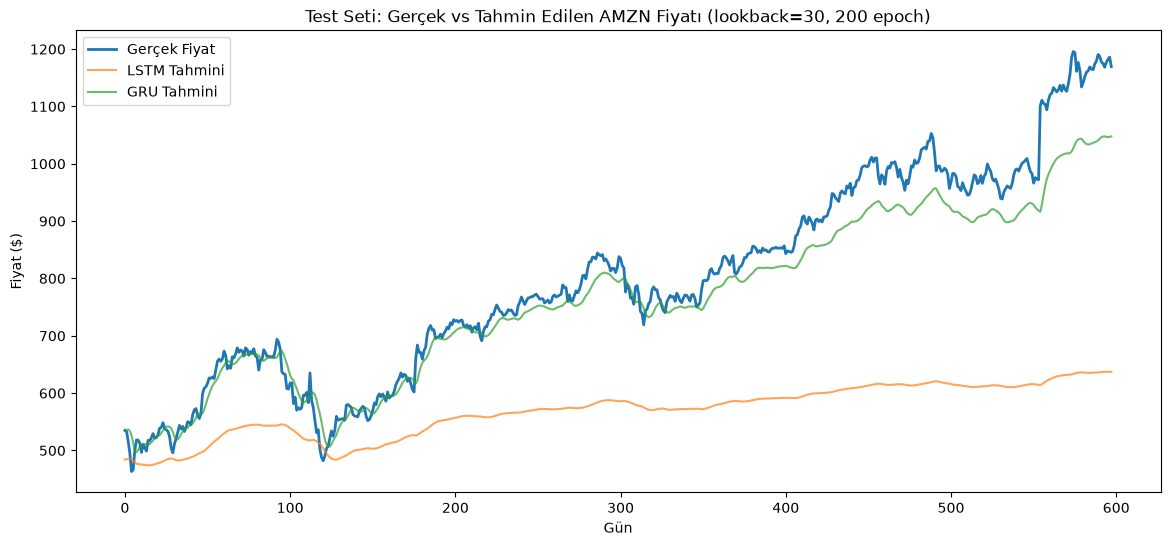

In [8]:
y_test_actual = scaler.inverse_transform(y_test.numpy())
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm.numpy())
y_pred_gru_actual = scaler.inverse_transform(y_pred_gru.numpy())

plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Gerçek Fiyat', linewidth=2)
plt.plot(y_pred_lstm_actual, label='LSTM Tahmini', alpha=0.7)
plt.plot(y_pred_gru_actual, label='GRU Tahmini', alpha=0.7)
plt.title('Test Seti: Gerçek vs Tahmin Edilen AMZN Fiyatı (lookback=30, 200 epoch)')
plt.xlabel('Gün')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.show()

## Sonuçlar ve Karşılaştırma

| Model | Lookback | Epoch | Test RMSE |
|-------|----------|-------|-----------|
| LSTM  | 20       | 200   | 0.508     |
| GRU   | 20       | 200   | 0.186     |
| LSTM  | 30       | 200   | 0.454     |
| GRU   | 30       | 200   | **0.089** |

**Bulgular:**
- GRU, tüm denemelerde LSTM'den daha düşük test hatası (RMSE) elde etti.
- Lookback penceresini 20'den 30 güne çıkarmak her iki modeli de iyileştirdi, ancak GRU (%52 iyileşme) LSTM'e (%11 iyileşme) göre çok daha fazla fayda gördü.
- Bu, GRU'nun bu veri setinde daha uzun geçmiş bağlamı daha verimli kullandığını gösteriyor; LSTM'in daha karmaşık iç yapısı, aynı epoch sayısında bu ekstra bilgiyi tam değerlendirememiş olabilir.
- Modeller, genel fiyat trendini takip edebiliyor ancak özellikle hızlı yükseliş dönemlerinde gerçek fiyatın bir miktar altında kalıyor — bu, zaman serisi tahmininde yaygın görülen bir "gecikme" (lag) davranışıdır.

**Sonraki adımlar (gelecekte denenebilir):** Daha fazla epoch ile LSTM eğitimi, ek özellikler (Volume, Open/High/Low), farklı hidden_size değerleri, veya dikkat mekanizmaları (attention).